In [1]:
import pandas as pd
from sklearn.datasets import load_iris
iris=load_iris()


In [2]:
dir(iris)


['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [3]:
iris.data[0:5]


array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [4]:
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [6]:
df['target']=iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
iris.target_names


array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [9]:
df[df.target==1].head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
50,7.0,3.2,4.7,1.4,1
51,6.4,3.2,4.5,1.5,1
52,6.9,3.1,4.9,1.5,1
53,5.5,2.3,4.0,1.3,1
54,6.5,2.8,4.6,1.5,1


In [11]:
df['flower_name']=df.target.apply(lambda x: iris.target_names[x])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [12]:
import matplotlib.pyplot as plt
%matplotlib inline

In [13]:
df0=df[df.target==0]
df1=df[df.target==1]
df2=df[df.target==2]

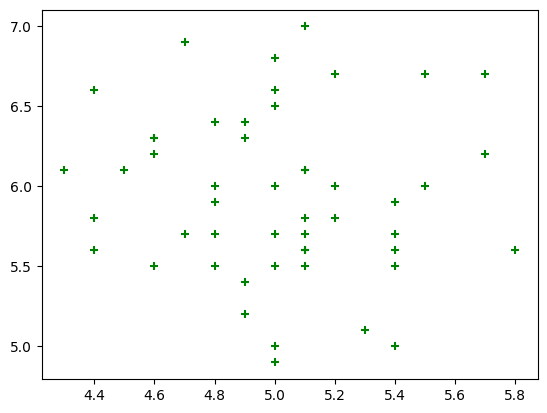

In [14]:
plt.scatter(df0['sepal length (cm)'],df1['sepal length (cm)'],marker='+',color='green')

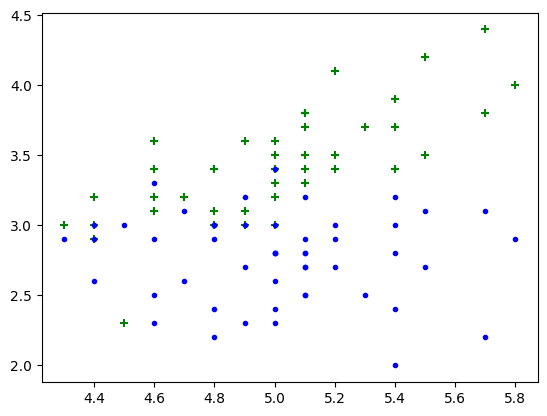

In [19]:
plt.scatter(df0['sepal length (cm)'],df0['sepal width (cm)'],marker='+',color='green')
plt.scatter(df0['sepal length (cm)'],df1['sepal width (cm)'],marker='.',color='blue')

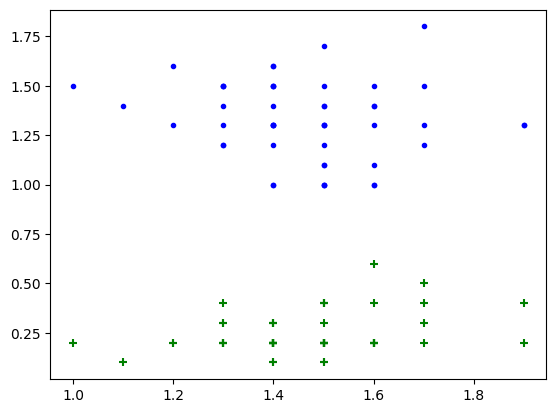

In [20]:
plt.scatter(df0['petal length (cm)'],df0['petal width (cm)'],marker='+',color='green')
plt.scatter(df0['petal length (cm)'],df1['petal width (cm)'],marker='.',color='blue')

In [21]:
from sklearn.model_selection import train_test_split


In [22]:
x=df.drop(['target','flower_name'],axis='columns')
x.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [23]:
y=df.target


In [25]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8)
len(x_train)

120

In [26]:
len(x_test)

30

In [29]:
from sklearn.svm import SVC
model=SVC()
model.fit(x_train,y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [31]:
model.predict(x_test)

array([2, 2, 2, 2, 0, 0, 2, 0, 1, 2, 0, 2, 1, 0, 2, 1, 2, 2, 0, 0, 0, 2,
       1, 2, 1, 2, 1, 2, 2, 2])

In [32]:
y_test


143    2
117    2
144    2
120    2
41     0
25     0
115    2
22     0
99     1
136    2
42     0
109    2
92     1
9      0
131    2
60     1
114    2
134    2
14     0
32     0
24     0
113    2
79     1
103    2
56     1
142    2
123    2
105    2
148    2
145    2
Name: target, dtype: int64

In [34]:
model.score(x_test,y_test)

0.9666666666666667